**Hyper parameter tuning**

- The parameters or arguments of model can change by user to get the good model performance

- Two methods:- 1. Grid search
                
                 2. Random search


- Assume that in Decsision tree we have following hyper parameter

    - criterion : {"gini", "entropy", "log_loss"}
 
    - splitter : {"best", "random"}
 
    - max_depth : {1,2,3,4,5,6}
 
- By default we have criterion 'gini' is there

- Bt the model might be performed when criterion is 'entropy' also

- we need to test the combination by providing different values

- To try the combinations we have 2 methods

    - Grid search:

        - it is a step by step by consider the all combinations
     
        - in criterian=3, splitter=2, max depath=6
     
        - The total Combination  are : 3*2*6=36,   this is called "grid search"
     
    - Random search:
 
        - It will select randomly some combinations
     
        - It will not do all 36 possible combinations, this is called "Random search"
     
- Generally we do Grid search

- By doing this we have  term called Cross validation


**Cross validation**

- Cross validation : CV

- CV , we divide data randomly into 4 parts

- Out fo these 4 parts every time 3 parts consider as train data, 1 part consider as test data

- P1 P2 P3 P4 are 4 parts of data

- Combination-1: P1+P2+P3 are train data and P4 as test data

        - For Combination-1 will  try to imporove model performance by doing Hyper parameter tuning

        - Assume there 36 combinations are available in DT

        - For the Combination will do all 36

- Combination-2: P1+P2+P4 are train data and P3 as test data

        - For Combination-2 will  try to imporove model performance by doing Hyper parameter tuning

        - Assume there 36 combinations are available in DT

        - For the Combination will do all 36

- Combination-3: P1+P3+P4 train data and P2 as test data

        - For Combination-3 will  try to imporove model performance by doing Hyper parameter tuning

        - Assume there 36 combinations are available in DT

        - For the Combination will do all 36

- Combination-4: P2+P3+P4 train data and P1 as test data

        - For Combination-4 will  try to imporove model performance by doing Hyper parameter tuning

        - Assume there 36 combinations are available in DT

        - For the Combination will do all 36

- Finally will consider the average of all 4 combinations is the output

- Combination-1 has accuracy-1

- Combination-2 has accuracy-2

- Combination-3 has accuracy-3

- Combination-4 has accuracy-4

- Accuracy=avg(acc1+acc2+acc3+acc4)

In [2]:
from sklearn.tree import DecisionTreeClassifier
DecisionTreeClassifier()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [3]:
import pandas as pd                                                               # 86 th class
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes=True)                   # To get different colors
pd.set_option('display.max_columns',None)         # To display the max columns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report, roc_auc_score,roc_curve

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [4]:
data=pd.read_csv('Preprocessed_data.csv')
data

,Unnamed: 0,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Avg Monthly Long Distance Charges,Multiple Lines,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,0,0,37,1,0,34.827662,-118.999073,2,9,5,42.39,0,0,16.0,0,1,0,1,1,0,0,1,1,1,1,65.60,593.30,0.00,0,381.51,974.81,1
1,1,1,46,0,0,34.162515,-118.203869,0,9,5,10.69,1,0,10.0,0,0,0,0,0,1,1,0,0,0,1,-4.00,542.40,38.33,10,96.21,610.28,1
2,2,1,50,0,0,33.645672,-117.922613,0,4,4,33.65,0,2,30.0,0,0,1,0,0,0,0,1,0,1,0,73.90,280.85,0.00,0,134.60,415.45,0
3,3,1,78,1,0,38.014457,-122.115432,1,13,3,27.82,0,2,4.0,0,1,1,0,1,1,0,1,0,1,0,98.00,1237.85,0.00,0,361.66,1599.51,0
4,4,0,75,1,0,34.227846,-119.079903,3,3,5,7.38,0,2,11.0,0,0,0,1,1,0,0,1,0,1,1,83.90,267.40,0.00,0,22.14,289.54,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4830,7036,0,53,0,0,36.807595,-118.901544,0,1,4,42.09,0,2,9.0,0,0,0,0,0,0,0,1,0,1,1,70.15,70.15,0.00,0,42.09,112.24,0
4831,7038,0,20,0,0,32.759327,-116.997260,0,13,3,46.68,0,1,59.0,1,0,0,1,0,0,1,1,1,0,1,55.15,742.90,0.00,0,606.84,1349.74,1
4832,7039,1,40,1,0,37.734971,-120.954271,1,22,3,16.20,1,2,17.0,0,0,0,0,0,1,1,1,0,1,0,85.10,1873.70,0.00,0,356.40,2230.10,0
4833,7040,1,22,0,0,39.108252,-123.645121,0,2,4,18.62,0,1,51.0,0,1,0,0,0,0,0,1,0,1,1,50.30,92.75,0.00,0,37.24,129.99,1


In [5]:
# Here the target column is customer status
X = data.drop('Customer Status', axis=1)
y = data['Customer Status']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape),

(3868, 31)
(967, 31)
(3868,)
(967,)


(None,)

In [7]:
from sklearn.model_selection import GridSearchCV,cross_val_score
grid_tree=DecisionTreeClassifier()        # Base model
grid_tree

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
grid_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

- max_depth : 
    The maximum depth of the tree. If None, then nodes are expanded until
    all leaves are pure or until all leaves contain less than
    min_samples_split samples.

- min_samples_split : 
    The minimum number of samples required to split an internal node:
        
- min_samples_split : 
    The minimum number of samples required to split an internal node:

In [9]:
# You need to create dictionary with hyper parameters

param_grid ={
    "criterion":['gini','entropy'],
    "max_depth":[3,4,5,6],
    "min_samples_split": [2,3,4],
    "min_samples_leaf": [1,2,3,4],
    "random_state": [0,42]
}

In [10]:
# now these parameters to apply in a DT model
import time

start= time.time()
grid_search = GridSearchCV(grid_tree,      # Base model
                          param_grid,      # params
                          scoring='accuracy',       # metric
                          cv=5,
                          verbose=True)


end=time.time()
print("total time taken is:",(end-start))
grid_search

total time taken is: 0.0001652240753173828


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [11]:
dir(grid_search)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_refit_for_multimetric',
 '_check_scorers_accept_sample_weight',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr

In [12]:
import time
start=time.time()
grid_search.fit(X_train, y_train)
end=time.time()
print("Total time taken is:",(end-start))

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Total time taken is: 90.60556364059448


In [13]:
grid_search.best_estimator_
# Estimator means model : 144 models

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
grid_search.best_score_

np.float64(0.7861889146283982)

In [15]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 6,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'random_state': 42}

**Cross Validation score**

In [16]:
# Assume that we already know the best model
# best parameters with out doing Grid search
# Now I want to apply Cross validation
# In the cross validation every part involved in traning and testing

In [17]:
accuracy_list=cross_val_score(grid_search.best_estimator_,
                X_train,
                y_train,
                scoring='accuracy')

In [18]:
accuracy_list.mean()

np.float64(0.7861889146283982)

In [19]:
# All together

# ============= Step-1: Get the base model =========================

from sklearn.model_selection import GridSearchCV,cross_val_score
grid_tree=DecisionTreeClassifier()        # Base model
DT_params=[keys for keys in grid_tree.get_params()]
print("Available parameters for model:",DT_params)

#=== Step-2: You need to create dictionary with hyper parameters ============

param_grid ={
    "criterion":['gini','entropy'],
    "max_depth":[3,4,5,6],
    "min_samples_split": [2,3,4],
    "min_samples_leaf": [1,2,3,4],
    "random_state": [0,42]
}

print("Processing parameters are:",param_grid)

#===================Step-3 Apply Grid search =======================
grid_search = GridSearchCV(grid_tree,      # Base model
                          param_grid,      # params
                          scoring='accuracy',       # metric
                          cv=5,
                          verbose=True)

#================= Step-4: fit the model with train data==============
grid_search.fit(X_train,y_train)

#================ Step-5: Get the best parameters====================
best_params=grid_search.best_params_
best_score=grid_search.best_score_
print("best params:",best_params)
print("best train accuracy:", best_score)

Available parameters for model: ['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state', 'splitter']
Processing parameters are: {'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, 5, 6], 'min_samples_split': [2, 3, 4], 'min_samples_leaf': [1, 2, 3, 4], 'random_state': [0, 42]}
Fitting 5 folds for each of 192 candidates, totalling 960 fits
best params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 2, 'random_state': 42}
best train accuracy: 0.7861889146283982


**Identify the predictions and Metrics by using best parameters**
- 87th class

  
- Out of 1440 fittings, one best fit model is outcome
- Best fit means it will give the best parameters
- For me the best parameter combination is
    - entropy
    - depth=6
    - sample leaf=3
    - sample split=2
    - random state=0
- our goal is by using above parameter we need to find the predictions
- and will evaluate model performance
- For that Import Decision Tree and pass the best parameters
- now fit that model with X_train,y_train
- Get the predictions by passing X_test
- Compare the predictions with y_test
- calculate
    - Accuracy
    - precision
    - Recall
    - F1 score
    - Roc-Auc curve

accurcay is: 80.46
F1 is: 0.86
Precision is: 0.85
Recall is: 0.86
              precision    recall  f1-score   support

           0       0.70      0.68      0.69       308
           1       0.85      0.86      0.86       659

    accuracy                           0.80       967
   macro avg       0.78      0.77      0.77       967
weighted avg       0.80      0.80      0.80       967



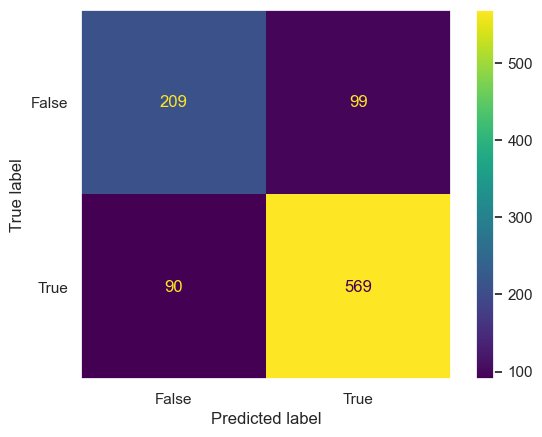

True negative: 209
False positive: 99
False negative: 90
True positive: 569


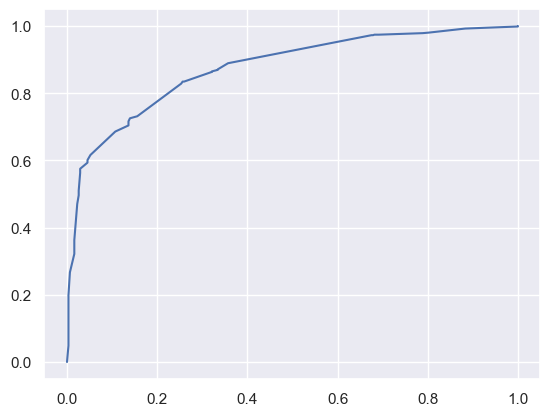

In [23]:
from sklearn.tree import DecisionTreeClassifier           # 87 th class
dtree=DecisionTreeClassifier(criterion='gini',
                             max_depth=6,
                             min_samples_leaf=3,
                             min_samples_split=2,
                             random_state=42)
dtree.fit(X_train, y_train)

# ================= step-5: predictions ====================================

y_pred_dt=dtree.predict(X_test)

# ================ Step-6: Metrics ========================================

acc_dt=round(accuracy_score(y_test,y_pred_dt)*100,2)
f1_dt=round(f1_score(y_test,y_pred_dt),2)
precision_dt=round(precision_score(y_test,y_pred_dt),2)
recall_dt=round(recall_score(y_test,y_pred_dt),2)

print("accurcay is:",acc_dt)
print("F1 is:",f1_dt)
print("Precision is:",precision_dt)
print("Recall is:",recall_dt)
print(classification_report(y_test,y_pred_dt))

# ======================== step-7: confusion matrix ===========================

cmt=confusion_matrix(y_test,y_pred_dt)
disp=ConfusionMatrixDisplay(confusion_matrix=cmt,display_labels = [False, True])

disp.plot()
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test,y_pred_dt).ravel()
print("True negative:",tn)
print("False positive:",fp)
print("False negative:",fn)
print("True positive:",tp)

# ========================= Step-8: ROC-AUC curve =============================

y_dt_pred_prob=dtree.predict_proba(X_test)[:,1]  # Class-1 probabilities
fpr,tpr,threshold=roc_curve(y_test,y_dt_pred_prob)
plt.plot(fpr,tpr)

**Important features**

In [24]:
# Decision tree will provide importsnt features aslo
# Information gain values
dtree.feature_importances_

array([0.        , 0.00273856, 0.0938925 , 0.        , 0.03563606,
       0.01151999, 0.00218206, 0.20139198, 0.04876956, 0.        ,
       0.01155306, 0.        , 0.        , 0.01225063, 0.00423902,
       0.        , 0.        , 0.        , 0.        , 0.00775328,
       0.        , 0.        , 0.45524239, 0.        , 0.        ,
       0.05528315, 0.0272378 , 0.00081539, 0.00437184, 0.00901175,
       0.01611098])

In [25]:
imp_df = pd.DataFrame({"Feature Name":X_train.columns,
                       "Importance": dtree.feature_importances_
                      })
fi = imp_df.sort_values(by="Importance", ascending=False)
fi

# This concept is valid for only Decision tree
# you can use these features top 10 again develop the model
# Don't use tis feature in another model

,Feature Name,Importance
22,Contract,0.455242
7,Number of Referrals,0.201392
2,Age,0.093892
25,Monthly Charge,0.055283
8,Tenure in Months,0.048770
4,Number of Dependents,0.035636
26,Total Charges,0.027238
30,Total Revenue,0.016111
13,Avg Monthly GB Download,0.012251
10,Avg Monthly Long Distance Charges,0.011553
